<a href="https://colab.research.google.com/github/vivek-rd/deep-rec-sys-amazon-reviews/blob/dev/HSACN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install datasets

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
import re

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from datasets import load_dataset

In [ ]:
#this is basically users dataset coz only users have the associated reviews, not the items. So we don't need items data at all if only going with reviews.

dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Appliances", split= 'full', trust_remote_code=True)
dataset[0]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/30.3k [00:00<?, ?B/s]

Amazon-Reviews-2023.py:   0%|          | 0.00/39.6k [00:00<?, ?B/s]

Appliances.jsonl:   0%|          | 0.00/929M [00:00<?, ?B/s]

Generating full split: 0 examples [00:00, ? examples/s]

{'rating': 5.0,
 'title': 'Work great',
 'text': 'work great. use a new one every month',
 'images': [],
 'asin': 'B01N0TQ0OH',
 'parent_asin': 'B01N0TQ0OH',
 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ',
 'timestamp': 1519317108692,
 'helpful_vote': 0,
 'verified_purchase': True}

In [ ]:
df= dataset.to_pandas()
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Work great,work great. use a new one every month,[],B01N0TQ0OH,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1519317108692,0,True
1,5.0,excellent product,Little on the thin side,[],B07DD2DMXB,B07DD37QPZ,AHWWLSPCJMALVHDDVSUGICL6RUCA,1664746863446,0,True
2,5.0,Happy customer!,"Quick delivery, fixed the issue!",[],B082W3Z9YK,B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,1607225435363,0,True
3,5.0,Amazing value,I wasn't sure whether these were worth it or n...,[],B078W2BJY8,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,1534104184306,0,True
4,5.0,Dryer parts,Easy to install got the product expected to re...,[],B08C9LPCQV,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,1620176603754,0,True


In [ ]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['sentence_count'] = df['text'].apply(lambda x: len(sent_tokenize(x)))

print("Word Count Statistics:")
print(df['word_count'].describe())

print("\nSentence Count Statistics:")
print(df['sentence_count'].describe())

Word Count Statistics:
count    2.128605e+06
mean     3.149559e+01
std      5.160581e+01
min      0.000000e+00
25%      7.000000e+00
50%      1.600000e+01
75%      3.700000e+01
max      3.636000e+03
Name: word_count, dtype: float64

Sentence Count Statistics:
count    2.128605e+06
mean     2.619201e+00
std      2.709329e+00
min      0.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      2.050000e+02
Name: sentence_count, dtype: float64


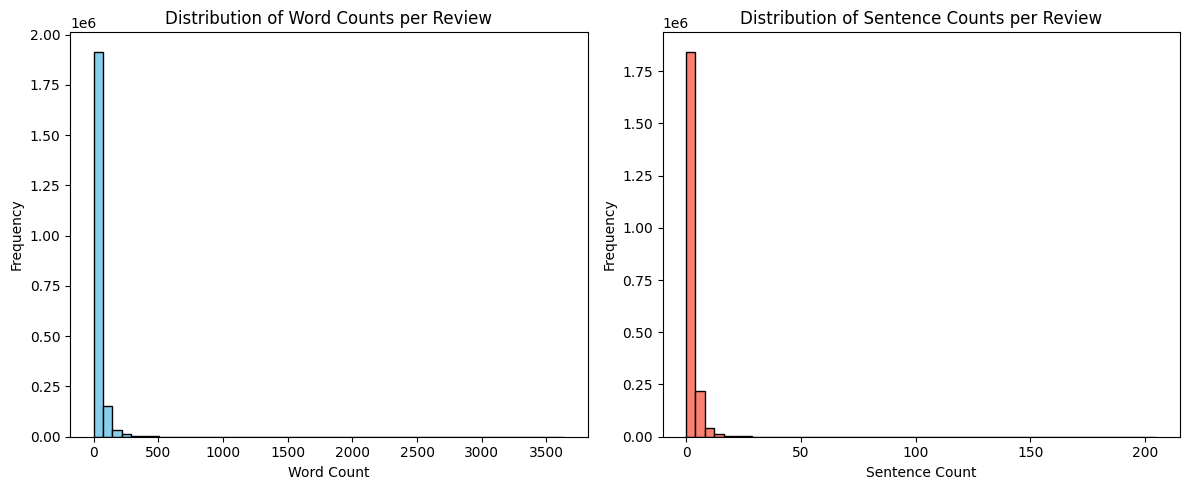

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['word_count'], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Word Counts per Review")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(df['sentence_count'], bins=50, color='salmon', edgecolor='black')
plt.title("Distribution of Sentence Counts per Review")
plt.xlabel("Sentence Count")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Most of the Word Count is concentrated between 0 to 500 and Sentence Count between 0 to 30 atmost, so zooming in on that.

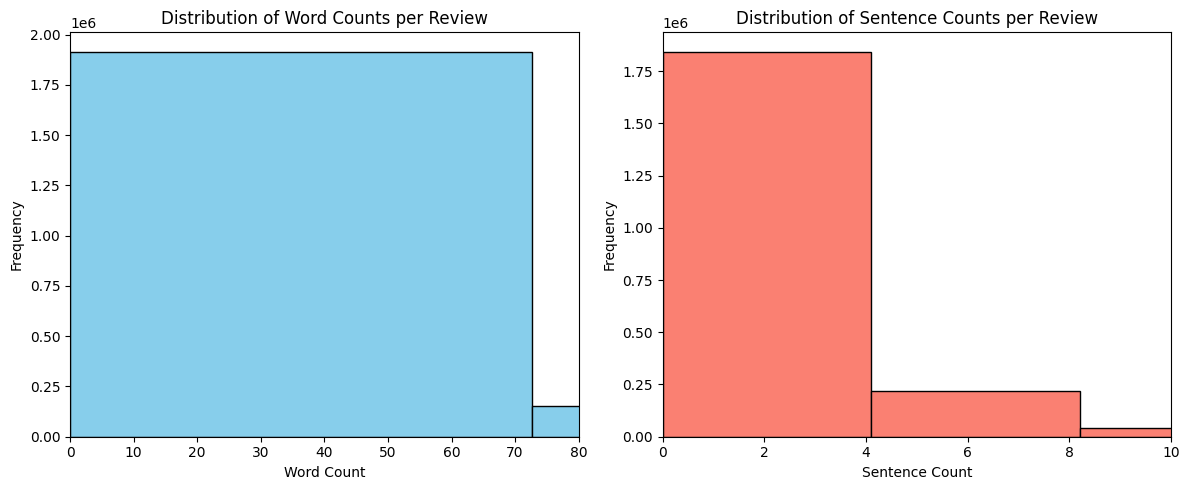

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['word_count'], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Word Counts per Review")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.xlim(0, 80) #plt.xlim(0, 500)

plt.subplot(1, 2, 2)
plt.hist(df['sentence_count'], bins=50, color='salmon', edgecolor='black')
plt.title("Distribution of Sentence Counts per Review")
plt.xlabel("Sentence Count")
plt.ylabel("Frequency")
plt.xlim(0, 10) #plt.xlim(0, 30)

plt.tight_layout()
plt.show()

So it's safe to assume we would have 100 words per review, and 7 sentences per review (after changing the limits, the number changed to 70, 4 on further experiments). The catch is, we want words per sentences for the sentence encoder and not words per review. It would be time consuming to calculate that so we can settle for approximating by (words_per_review / sentence_per_review) to get words_per_sentence.

In [ ]:
avg_words = df['word_count'].mean()
avg_sentences = df['sentence_count'].mean()

avg_words_per_sentence = avg_words / avg_sentences

print("Average words per review:", avg_words)
print("Average sentences per review:", avg_sentences)
print("Estimated average words per sentence:", avg_words_per_sentence)

Average words per review: 31.495586076326983
Average sentences per review: 2.619200838107587
Estimated average words per sentence: 12.024883933330988


In [ ]:
item_reviews = df.groupby('parent_asin')['text'].apply(lambda x: ' '.join(x)).reset_index()
user_reviews= df.groupby('user_id')['text'].apply(lambda x: ' '.join(x)).reset_index()

In [ ]:
item_reviews['text'].describe()

,text
count,94319
unique,91577
top,Perfect fit
freq,91


# Model

In [ ]:
x = torch.randn(40, 5, 3)
x= x.transpose(1, 2)
#print(x)
convq= nn.Conv1d(in_channels= 3, out_channels= 4, kernel_size= 2)

print(convq)
#print(convq.weight)
print(convq.weight.shape)

output= convq(x)
print(output)



Conv1d(3, 4, kernel_size=(2,), stride=(1,))
torch.Size([4, 3, 2])
tensor([[[-1.1425e-01,  5.1490e-02,  5.7672e-01,  5.4183e-01],
         [-2.2356e-01, -7.4661e-01, -7.8322e-01, -1.0532e+00],
         [ 8.5333e-02,  1.1879e+00, -1.1683e-01, -3.0005e-02],
         [ 1.0751e+00,  1.6654e-01, -3.4273e-01,  5.3269e-01]],

        [[-7.6077e-01, -5.1144e-01, -9.9662e-02, -2.7993e-01],
         [ 8.1358e-01,  5.3059e-01, -2.1578e-01,  1.4104e-01],
         [ 1.2739e+00,  6.2843e-01,  8.0134e-01,  7.8937e-01],
         [ 2.3152e-01, -1.3165e-03, -3.0128e-02,  5.3813e-01]],

        [[-2.7572e-01,  5.7929e-01,  2.8565e-01,  5.5741e-01],
         [-8.9986e-01, -1.1242e+00, -4.7181e-01, -6.8828e-01],
         [ 1.3357e+00,  7.3821e-01,  4.0473e-01, -1.3916e-01],
         [ 1.2933e+00, -2.1581e-01,  1.2698e-01, -1.7089e-01]],

        [[ 3.5586e-01,  1.1775e+00,  4.1182e-01,  3.3611e-01],
         [-1.6141e-01, -1.0259e+00, -4.0678e-01, -2.9214e-01],
         [ 5.7258e-01, -8.1001e-01, -1.1037e-0

In [ ]:
batch_size = 1
seq_len = 5
input_dim = 3
dk = 4

x = torch.randn(batch_size, seq_len, input_dim)
print("input shape: ", x.shape)
print("input:")
print(x)
print("\n")
print("transposed:")
print(x.transpose(1, 2))

input shape:  torch.Size([1, 5, 3])
input:
tensor([[[-1.1167,  1.1166, -1.1288],
         [-1.5965, -0.8892, -0.1692],
         [ 0.5616,  0.1922, -0.2011],
         [-0.0751,  0.3749,  0.3235],
         [ 1.0190,  0.7707, -0.1383]]])


transposed:
tensor([[[-1.1167, -1.5965,  0.5616, -0.0751,  1.0190],
         [ 1.1166, -0.8892,  0.1922,  0.3749,  0.7707],
         [-1.1288, -0.1692, -0.2011,  0.3235, -0.1383]]])


In [ ]:
convq= nn.Conv1d(in_channels= input_dim, out_channels= 4, kernel_size= 2)
print(convq)
print(convq.weight)
print(convq.weight.shape)

Conv1d(3, 4, kernel_size=(2,), stride=(1,))
Parameter containing:
tensor([[[-0.2119,  0.3745],
         [-0.3651, -0.1777],
         [-0.0886,  0.3744]],

        [[-0.3325, -0.2306],
         [-0.3253, -0.0422],
         [ 0.1265,  0.2853]],

        [[-0.0431,  0.1442],
         [ 0.0701,  0.2823],
         [-0.2843,  0.1583]],

        [[-0.0176, -0.4059],
         [-0.3107,  0.1193],
         [-0.1555, -0.1897]]], requires_grad=True)
torch.Size([4, 3, 2])


In [ ]:
class SequenceEncodingModule(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_heads, max_seq_len):
        """
        Args:
            input_dim: Dimension of input embeddings, d.
            hidden_dim: Hidden dimension of this module, d_k.
            kernel_size: n (width for n-gram features)
            num_heads: Number of attention heads, H. (d_h = hidden_dim / num_heads)
            max_seq_len: Maximum sequence length (used for relative positional embeddings)
        """
        super(SequenceEncodingModule, self).__init__()
        self.input_dim = input_dim       # d - embedding dimension
        self.hidden_dim = hidden_dim     # d_k -  hidden layer dimension
        self.kernel_size = kernel_size   # n - ngram size
        self.num_heads = num_heads
        self.d_h = hidden_dim // num_heads  # subspace dimension d_h (assume hidden_dim divisible by num_heads)
        self.max_seq_len = max_seq_len

        # Convolution layers for computing q, k, v.
        # In PyTorch, Conv1d with kernel_size = n and padding = floor((n-1)/2) produces a sliding-window (concatenated) result.
        padding = kernel_size // 2  # floor((n-1)/2) works when n is odd.
        self.conv_q = nn.Conv1d(in_channels=input_dim, out_channels=hidden_dim, kernel_size=kernel_size, padding=padding)
        self.conv_k = nn.Conv1d(in_channels=input_dim, out_channels=hidden_dim, kernel_size=kernel_size, padding=padding)
        self.conv_v = nn.Conv1d(in_channels=input_dim, out_channels=hidden_dim, kernel_size=kernel_size, padding=padding)

        self.ff = nn.Linear(hidden_dim, hidden_dim)

        self.p_K = nn.Parameter(torch.randn(max_seq_len, max_seq_len, self.d_h))
        self.p_V = nn.Parameter(torch.randn(max_seq_len, max_seq_len, self.d_h))

    def forward(self, x):
        """
        Args:
            x: Tensor of shape (batch, seq_len, input_dim)
        Returns:
            z: Tensor of shape (batch, seq_len, hidden_dim) after encoding.
        """
        batch, t, _ = x.size()
        # First, apply convolution. Conv1d expects (batch, channels, seq_len).
        x_conv = x.transpose(1, 2)  # (batch, input_dim, t)
        q = F.relu(self.conv_q(x_conv))  # (batch, hidden_dim, t)
        k = F.relu(self.conv_k(x_conv))
        v = F.relu(self.conv_v(x_conv))
        # Bring back to shape (batch, t, hidden_dim)
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)
        # Split each into H heads: reshape from (batch, t, hidden_dim) to (batch, H, t, d_h)
        q = q.view(batch, t, self.num_heads, self.d_h).transpose(1, 2)  # (batch, num_heads, t, d_h)
        k = k.view(batch, t, self.num_heads, self.d_h).transpose(1, 2)
        v = v.view(batch, t, self.num_heads, self.d_h).transpose(1, 2)

        # Standard attention scores: for each head h, for positions i and j: score_std[i,j] = <q_i^h, k_j^h>
        scores_std = torch.matmul(q, k.transpose(-2, -1))  # (batch, num_heads, t, t)

        # Relative position term for keys:
        # p_K has shape (max_seq_len, max_seq_len, d_h). Slice to current sequence length.
        p_K = self.p_K[:t, :t, :]  # (t, t, d_h) PyTorch is fucking weird.

        # extra scores: for each head h, each position i and j, e_relative[i,j] = <q_i^h, p_K[i,j]>
        # We do this by broadcasting: (batch, num_heads, t, 1, d_h) * (1, 1, t, t, d_h) -> sum over d_h.
        e_relative = (q.unsqueeze(3) * p_K.unsqueeze(0).unsqueeze(0)).sum(-1)  # (batch, num_heads, t, t)

        # Total attention scores:
        scores = (scores_std + e_relative) / math.sqrt(self.d_h)  # (batch, num_heads, t, t)
        attn = F.softmax(scores, dim=-1)  # attention weights a_{ij}^h

        # Computing attention output.
        # First, weighted sum for v:
        z_v = torch.matmul(attn, v)  # (batch, num_heads, t, d_h)
        # Now add relative contribution from values using p_V.
        p_V = self.p_V[:t, :t, :]  # (t, t, d_h)
        # For each i, add: sum_j a_{ij}^h * p_V^{ij}
        z_p = (attn.unsqueeze(-1) * p_V.unsqueeze(0).unsqueeze(0)).sum(dim=-2)  # (batch, num_heads, t, d_h)
        z = z_v + z_p  # (batch, num_heads, t, d_h)

        # Concatenate all heads: from (batch, num_heads, t, d_h) to (batch, t, hidden_dim)
        z = z.transpose(1, 2).contiguous().view(batch, t, self.hidden_dim)

        # feed-forward layer with ReLU (W_f and b_f in Equation (7))
        z = F.relu(self.ff(z))  # (batch, t, hidden_dim)
        return z

In [ ]:
input_dim = 50         # dimension of word embeddings
hidden_dim = 128       # d_k as in paper
kernel_size = 3        # n-gram width
num_heads = 4          # number of attention heads
max_seq_len = 10       # maximum sequence length


sentence_encoder = SequenceEncoder(input_dim, hidden_dim, kernel_size, num_heads, max_seq_len)
dummy_sentences = torch.randn(2, 8, input_dim)  # shape: (batch=2, seq_len=8, input_dim=50)

sentence_representations = sentence_encoder(dummy_sentences)
print("Sentence representations shape:", sentence_representations.shape)

In [ ]:
class SequenceAggregatingModule(nn.Module):
    def __init__(self, hidden_dim):

        #hidden_dim: d_k (the same hidden dimension used in encoding)

        super(SequenceAggregatingModule, self).__init__()
        self.hidden_dim = hidden_dim
        self.d_p = hidden_dim // 2  # per paper, d_p = d_k/2
        self.W_p = nn.Linear(hidden_dim, self.d_p)  # This covers multiplication by W_p and addition of b_p.
        # h is a learnable vector in R^(d_p)
        self.h = nn.Parameter(torch.randn(self.d_p))

    def forward(self, z):

        # intermediate representation: r_i = ReLU(W_p z_i + b_p)
        r = F.relu(self.W_p(z))  # (batch, seq_len, d_p)
        # importance scores: score_i = h^T r_i.
        scores = torch.matmul(r, self.h)  # (batch, seq_len)
        # Normalizing to obtain attention weights a_i.
        attn = F.softmax(scores, dim=-1)  # (batch, seq_len)
        # Weighted sum of z_i's.
        l = torch.sum(z * attn.unsqueeze(-1), dim=1)  # (batch, hidden_dim)
        return l

In [ ]:
class SequenceEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_heads, max_seq_len):
        super(SequenceEncoder, self).__init__()
        self.encoding_module = SequenceEncodingModule(input_dim, hidden_dim, kernel_size, num_heads, max_seq_len)
        self.aggregating_module = SequenceAggregatingModule(hidden_dim)

    def forward(self, x):
        z = self.encoding_module(x)    # (batch, seq_len, hidden_dim)
        l = self.aggregating_module(z)  # (batch, hidden_dim)
        return l

In [ ]:
input_dim = 50         # dimension of word embeddings
hidden_dim = 128       # d_k as in paper
kernel_size = 3        # n-gram width
num_heads = 4          # number of attention heads
max_seq_len = 10       # maximum sequence length (e.g., maximum words per sentence)

sentence_encoder = SequenceEncoder(input_dim, hidden_dim, kernel_size, num_heads, max_seq_len)
dummy_sentences = torch.randn(2, 8, input_dim)  # shape: (batch=2, seq_len=8, input_dim=50)
sentence_representations = sentence_encoder(dummy_sentences)  # shape: (2, hidden_dim)
print("Sentence representations shape:", sentence_representations.shape)  # Expected: (2, 128)


review_encoder = SequenceEncoder(hidden_dim, hidden_dim, kernel_size, num_heads, max_seq_len)

# Dummy review: 1 review with 3 sentences (each already encoded as a 128-d vector).
dummy_review_sentences = torch.randn(1, 3, hidden_dim)  # (batch=1, num_sentences=3, 128)
review_representation = review_encoder(dummy_review_sentences)  # (1, 128)
print("Review representation shape:", review_representation.shape)

# user with 2 reviews:
dummy_user_reviews = torch.randn(1, 2, hidden_dim)  # (batch=1, num_reviews=2, 128)
user_encoder = SequenceEncoder(hidden_dim, hidden_dim, kernel_size, num_heads, max_seq_len)
user_representation = user_encoder(dummy_user_reviews)  # (1, 128)
print("User representation shape:", user_representation.shape)

Sentence representations shape: torch.Size([2, 128])
Review representation shape: torch.Size([1, 128])
User representation shape: torch.Size([1, 128])
